# Single Chargingstation Validation

In [1]:
# Imports
import duckdb
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]
DATABASE_PATH = "../../database/eBuS.duckdb"
OUTPUT_PATH = Path(r"C:\Users\svens\Nextcloud\Masterarbeit\Grafiken\FinalPlots")
VEHICLE_DICT = {"Ebusco2.2electric12m": "Ebusco 2.2", "SolarisUrbino12electric": "Urbino 12", "SolarisUrbino18electric": "Urbino 18"}
#Station Hermmanplatz / Urbanstr.: 
HERMANNPLATZ = "cs_agg_11538_0_11530_46"
#Station An der Mühle: 
MUEHLE = "cs_agg_10671_36_11882_47_11989_25"
# Oskar Helene Heim
OSKAR = "cs_agg_11518_0_11838_49_11845_0_11523_30"

## Station Hermmanplatz / Urbanstr.

### Station Energy Charged over Time

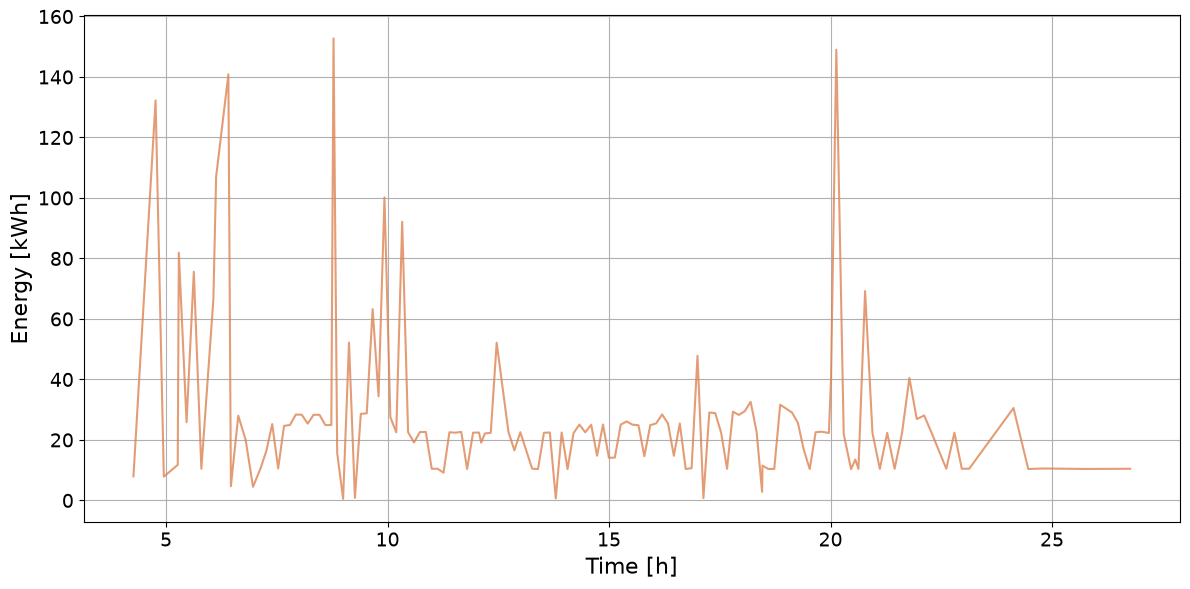

In [3]:
def single_station_events(station_id):
    con = duckdb.connect(DATABASE_PATH)

    df = con.execute(
        """
        SELECT chargingEvent_chargingBegin,
            chargingEvent_chargingEnd,
            chargingEvent_chargingStationId,
            chargingEvent_totalEnergyChargedIntoVehicle,
            scenario,
            seed,
        FROM multirun_chargingstations
        WHERE scenario = 'summer'
          AND seed = 65
          AND chargingEvent_chargingStationId = ?
          AND chargingEvent_totalEnergyChargedIntoVehicle > 0
        ORDER BY chargingEvent_chargingBegin
        """,
        [station_id]
    ).fetchdf()

    con.close()

    fig, ax = plt.subplots(figsize=(12, 6))


    ax.plot(
        df["chargingEvent_chargingBegin"] / 3600,
        df["chargingEvent_totalEnergyChargedIntoVehicle"] / 1000,
        alpha=0.8,
        color=PALETTE[1]
    )

    ax.set_xlabel("Time [h]", fontsize = 16)
    ax.set_ylabel("Energy [kWh]", fontsize = 16)
    ax.tick_params(axis='y', labelsize=14)
    ax.tick_params(axis='x', labelsize=14)
    ax.grid(True)

    fig.tight_layout()

    fig.savefig(
        OUTPUT_PATH / f"{station_id}_station_events.pdf",
            format="pdf",
            bbox_inches="tight"
        )

    plt.show()
    plt.close(fig)

single_station_events(OSKAR)

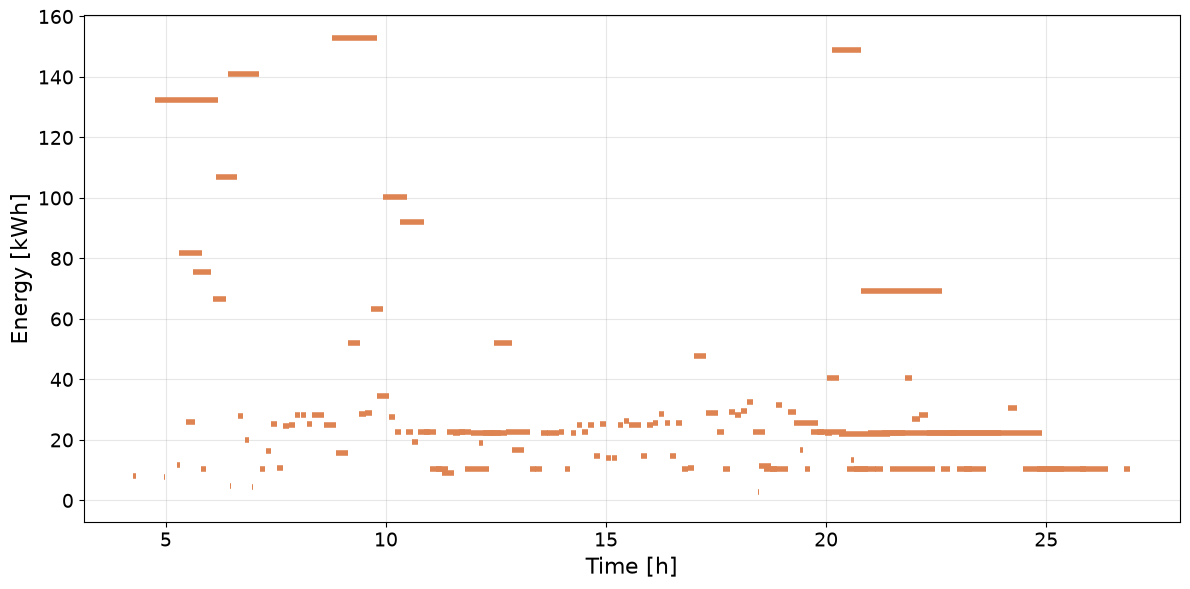

In [4]:
def single_station_events(station_id):
    con = duckdb.connect(DATABASE_PATH)

    df = con.execute(
        """
        SELECT chargingEvent_chargingBegin,
               chargingEvent_chargingEnd,
               chargingEvent_chargingStationId,
               chargingEvent_totalEnergyChargedIntoVehicle,
               scenario,
               seed
        FROM multirun_chargingstations
        WHERE scenario = 'summer'
          AND seed = 65
          AND chargingEvent_chargingStationId = ?
          AND chargingEvent_totalEnergyChargedIntoVehicle > 0
          AND chargingEvent_chargingEnd - chargingEvent_chargingBegin > 21
        ORDER BY chargingEvent_chargingBegin
        """,
        [station_id]
    ).fetchdf()

    con.close()

    fig, ax = plt.subplots(figsize=(12, 6))

    # Convert seconds to hours and energy to kWh
    start = df["chargingEvent_chargingBegin"] / 3600
    end = df["chargingEvent_chargingEnd"] / 3600
    energy = df["chargingEvent_totalEnergyChargedIntoVehicle"] / 1000

    # Draw one horizontal line for each charging event
    for s, e, y in zip(start, end, energy):
        ax.plot(
            [s, e],
            [y, y],
            color=PALETTE[1],
            linewidth=4,
            solid_capstyle="butt"
        )

    ax.set_xlabel("Time [h]", fontsize=16)
    ax.set_ylabel("Energy [kWh]", fontsize=16)

    ax.tick_params(axis="x", labelsize=14)
    ax.tick_params(axis="y", labelsize=14)

    ax.grid(True, alpha=0.3)

    fig.tight_layout()

    fig.savefig(
        OUTPUT_PATH / f"{station_id}_station_events.pdf",
        format="pdf",
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)


single_station_events(OSKAR)

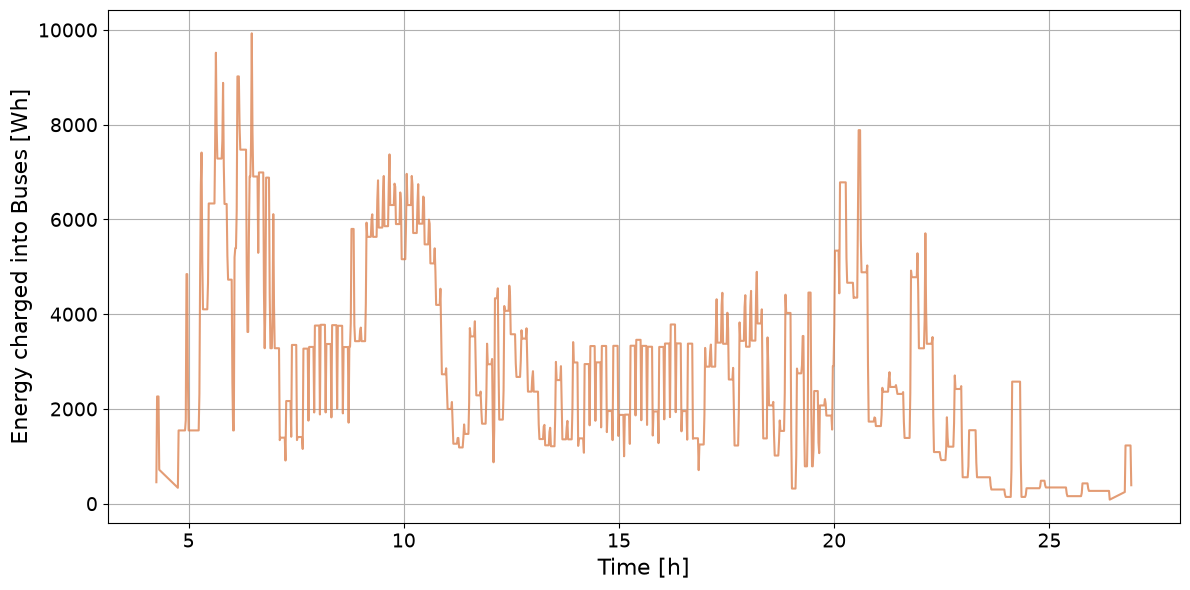

In [11]:
def single_station_charged_ess(station_id):
    con = duckdb.connect(DATABASE_PATH)

    df = con.execute(
        """
        SELECT
            timestep_time,
            station_energyChargedBus,
            scenario,
            seed
        FROM multirun_ess
        WHERE scenario = 'summer'
          AND seed = 65
          AND station_id = ?
          AND station_energyChargedBus > 0
        ORDER BY timestep_time
        """,
        [station_id]
    ).fetchdf()
    con.close()

    df["timestep_time"] = df["timestep_time"] / 3600
    df["station_energyChargedBus"] = df["station_energyChargedBus"]

    fig, ax = plt.subplots(figsize=(12, 6))


    ax.plot(
        df["timestep_time"],
        df["station_energyChargedBus"],
        alpha=0.8,
        color=PALETTE[1]
    )

    ax.set_xlabel("Time [h]", fontsize=16)
    ax.set_ylabel("Energy charged into Buses [Wh]", fontsize=16)

    ax.tick_params(axis="y", labelsize=14)
    ax.tick_params(axis="x", labelsize=14)

    ax.grid(True)

    fig.tight_layout()

    fig.savefig(
        OUTPUT_PATH / f"{station_id}_station_events.pdf",
        format="pdf",
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)


single_station_charged_ess(OSKAR)

### Station ESS SoC over Time

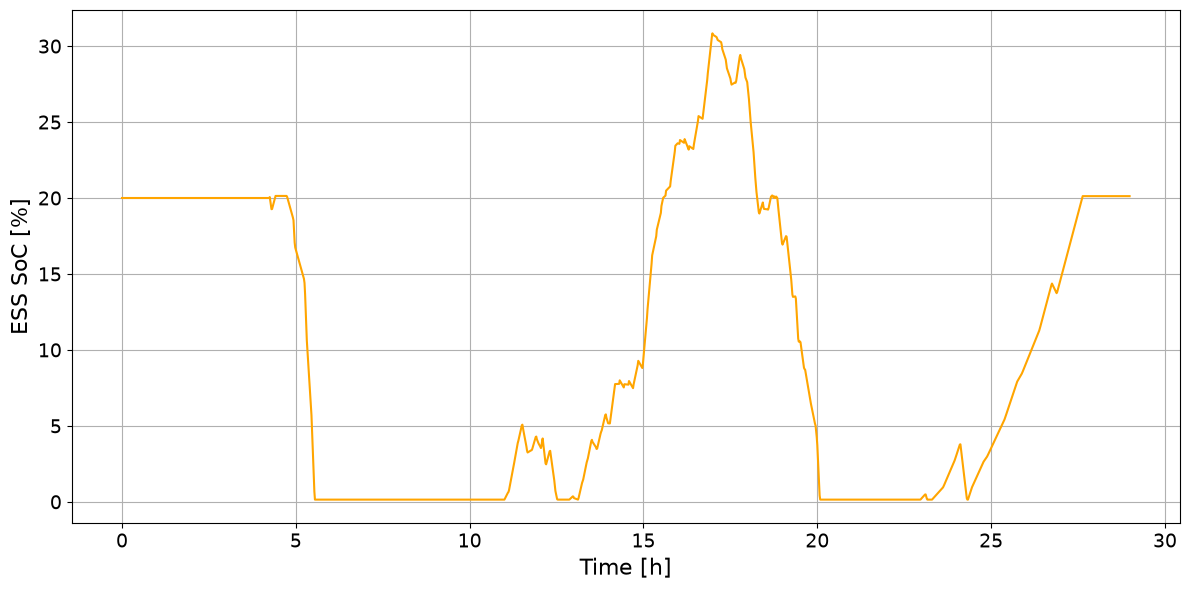

In [6]:
def single_station_events(station_id):
    con = duckdb.connect(DATABASE_PATH)

    df = con.execute(
        """
        SELECT
            timestep_time,
            station_essSoc,
            station_id,
            station_capacity,
            scenario,
            seed
        FROM multirun_ess
        WHERE seed = 65
        AND scenario = 'summer'
        AND station_id = ?
        ORDER BY timestep_time
        """,
        [station_id]
    ).fetchdf()

    con.close()

    df["timestep_time"] = df["timestep_time"] / 3600
    df["station_essSoc_pct"] = df["station_essSoc"] / df["station_capacity"] * 100

    fig, ax = plt.subplots(figsize=(12, 6))


    ax.plot(
        df["timestep_time"],
        df["station_essSoc_pct"],
        color="orange",
        label=station_id
    )

    ax.set_xlabel("Time [h]", fontsize=16)
    ax.set_ylabel("ESS SoC [%]", fontsize=16)
    ax.tick_params(axis="y", labelsize=14)
    ax.tick_params(axis="x", labelsize=14)
    ax.grid(True)

    plt.tight_layout()

    fig.savefig(
        OUTPUT_PATH / f"{station_id}_station_soc.pdf",
            format="pdf",
            bbox_inches="tight"
        )

    plt.show()
    plt.close(fig)

single_station_events(OSKAR)

### Single Station Stacked

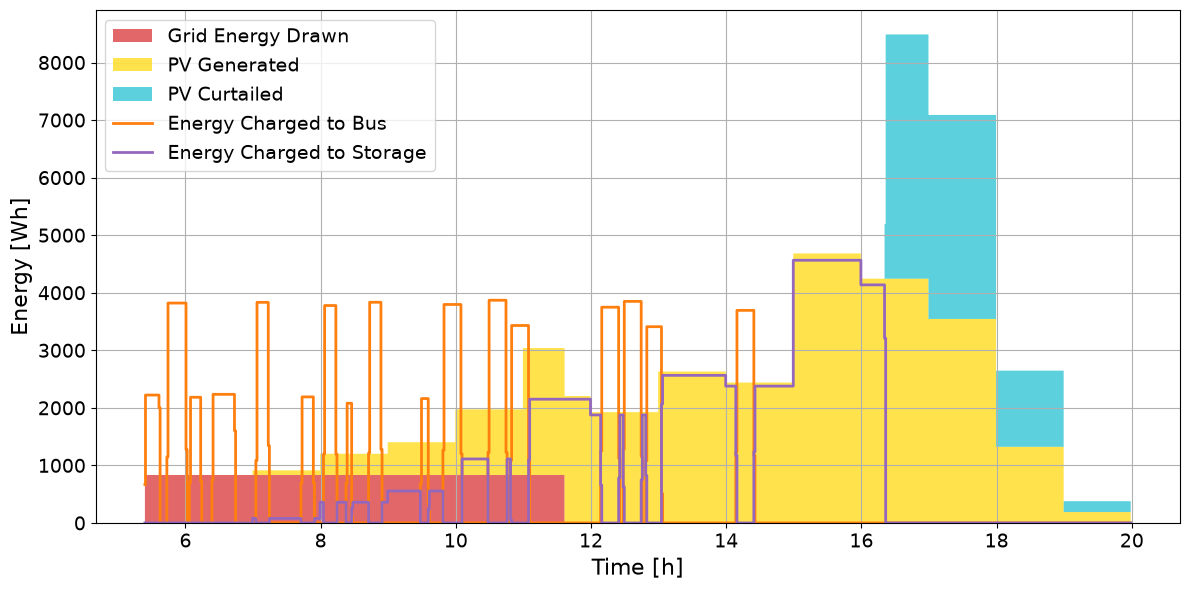

In [14]:
# AI-generated on 2026-09-25

def single_station_stacked(station_id):
    con = duckdb.connect(DATABASE_PATH)

    df = con.execute(
        """
        SELECT
            timestep_time,
            station_gridEnergyDrawn,
            station_pvCurtailed,
            station_pvGenerated,
            station_energyChargedBus,
            station_energyChargedStorage,
            scenario,
            seed
        FROM multirun_ess
        WHERE scenario = 'summer'
          AND seed = 65
          AND station_id = ?
          AND station_gridEnergyDrawn
              + station_pvGenerated
              + station_pvCurtailed > 0
        ORDER BY timestep_time
        """,
        [station_id]
    ).fetchdf()

    con.close()

    # Energy values are Wh per 1-minute timestep.
    # Convert them to kWh per timestep for plotting.
    energy_columns = [
        "station_gridEnergyDrawn",
        "station_pvGenerated",
        "station_pvCurtailed",
        "station_energyChargedBus",
        "station_energyChargedStorage",
    ]

    for column in energy_columns:
        df[column] = df[column] / 1

    # timestep_time is in seconds -> hours
    df["timestep_time"] = df["timestep_time"] / 3600

    fig, ax = plt.subplots(figsize=(12, 6))

    # Energy supplied to the station
    ax.stackplot(
        df["timestep_time"],
        df["station_gridEnergyDrawn"],
        df["station_pvGenerated"],
        df["station_pvCurtailed"],
        alpha=0.7,
        step="mid",
        labels=[
            "Grid Energy Drawn",
            "PV Generated",
            "PV Curtailed",
        ],
        colors=[
            "tab:red",
            "gold",
            "tab:cyan",
        ],
    )

    # Energy consumed/stored
    ax.step(
        df["timestep_time"],
        df["station_energyChargedBus"],
        where="mid",
        linewidth=2,
        label="Energy Charged to Bus",
        color="tab:orange",
    )

    ax.step(
        df["timestep_time"],
        df["station_energyChargedStorage"],
        where="mid",
        linewidth=2,
        label="Energy Charged to Storage",
        color="tab:purple",
    )

    ax.set_xlabel("Time [h]", fontsize=16)
    ax.set_ylabel("Energy [Wh]", fontsize=16)
    ax.tick_params(axis="y", labelsize=14)
    ax.tick_params(axis="x", labelsize=14)
    

    ax.legend(fontsize=14)
    ax.grid(True)

    fig.tight_layout()

    fig.savefig(
        OUTPUT_PATH / f"{station_id}_station_stacked.pdf",
        format="pdf",
        bbox_inches="tight",
    )

    plt.show()


single_station_stacked(MUEHLE)